## Multiple Linear Regression in Machine Learning


##

Multiple Linear Regression is a supervised learning algorithm in machine learning.
Supervised learning → the dataset has features (X) and a target variable (y).
The model learns the relationship between X and y to predict a continuous value.

mpg =β0+β1(cylinders)+β2(displacement)+β3(horsepower)+β4(weight)+β5(acceleration)+β6(model)+β7(origin)+β8(car_name )

## Workflow



## 
1.Load and inspect data

2.Exploratory Data Analysis (EDA)

Summary statistics

Visualization

Correlation matrix

Heatmap

3.Multicollinearity check

VIF

Identify highly correlated features

4.Train/Test split

Prevent data leakage

Keep test set untouched

5.Feature handling (on training set)

Remove correlated features

OR PCA

OR regularization (LASSO / Ridge)

6.Train model and Cross-validation (on training set)

Multiple Linear Regression

Estimate generalization

7.Compare models

Evaluate final model on test set

R²

RMSE

MAE

8.Interpret model

Coefficients

Feature importance

### Step 1: Load & inspect data

In [2]:
# read in cars dataset and mark all questionmarks as NaNs.
cars = pd.read_csv("data/cars_multivariate.csv",
                  na_values='?')
cars.head(n=2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320


In [17]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model         392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car_name      392 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 27.7+ KB


### Step 2: Correlation matrix → detect highly correlated features

In [4]:
# Calculate the correlation matrix for the cars dataset
import seaborn as sns
import matplotlib.pyplot as plt

corr = cars.corr(numeric_only=True)
corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
model,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


### Visulization of the correlation matrix: 

From the heatmap we can see that cylinders, displacement, horsepower and weight are strongly correlated with each other! and two four factors have a strong negative effect on the mpg!

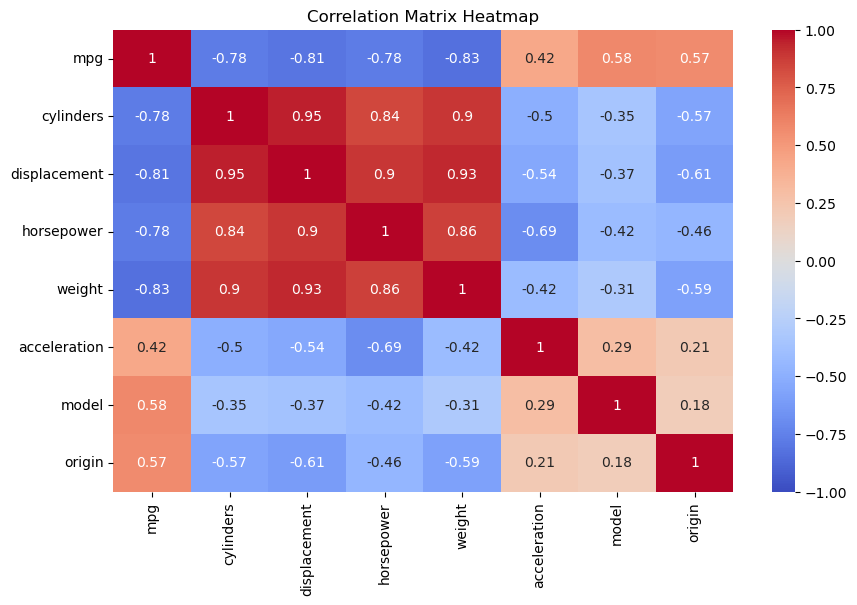

In [5]:
# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

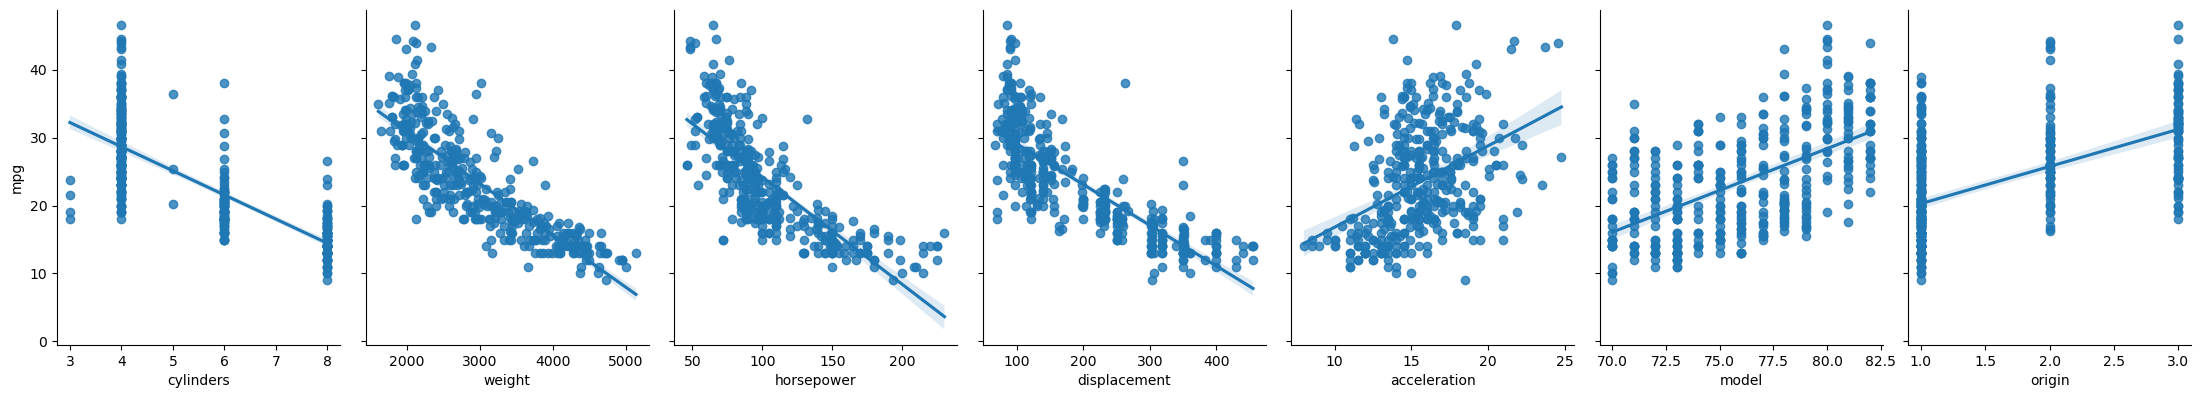

In [7]:
# Pairplot
sns.pairplot(cars, x_vars=['cylinders','weight','horsepower','displacement','acceleration','model', 'origin'], y_vars='mpg', height=4, aspect=0.8, kind='reg')
plt.show()

### Step 3: VIF → quantify multicollinearity

We can see that cylinders & weight & horsepower & displacement have high VIF values which means that this predictor is highly collinear with others and might cause instability in a regression model predicting mpg.

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X= cars[['cylinders','weight','horsepower','displacement','acceleration','model', 'origin']]
X_const = sm.add_constant(X)
vif = pd.DataFrame()
vif["Variable"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif)

       Variable         VIF
0         const  763.557531
1     cylinders   10.737535
2        weight   10.831260
3    horsepower    9.943693
4  displacement   21.836792
5  acceleration    2.625806
6         model    1.244952
7        origin    1.772386


### Step 4: Split Data into Training and Test Sets

In [19]:
from sklearn.model_selection import train_test_split

Y= cars['mpg']
# 70% training, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

### Step 5: Handle features (remove correlated, PCA, LASSO)

#### PCA

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X4 = cars[['cylinders','weight','horsepower','displacement','acceleration','model', 'origin']]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Number of components selected:", X_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_)

Number of components selected: 4
Explained variance ratio: [0.66237253 0.13656454 0.09953067 0.06963919]


#### Lasso Regression

In [26]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.5)

In [33]:
from sklearn.linear_model import Lasso
import pandas as pd

# Example
X5 = cars[['cylinders','weight','horsepower','displacement','acceleration','model','origin']]
Y = cars['mpg']

lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X5, Y)

# Create a dataframe to see coefficients
coef_df = pd.DataFrame({
    'Predictor': X5.columns,
    'Coefficient': lasso_model.coef_
})

# Show predictors that Lasso kept (non-zero coefficients)
adopted_predictors = coef_df[coef_df['Coefficient'] != 0]
print("Predictors adopted by Lasso:")
print(adopted_predictors)

Predictors adopted by Lasso:
      Predictor  Coefficient
1        weight    -0.006492
2    horsepower    -0.006599
3  displacement     0.000474
5         model     0.706375
6        origin     0.007479


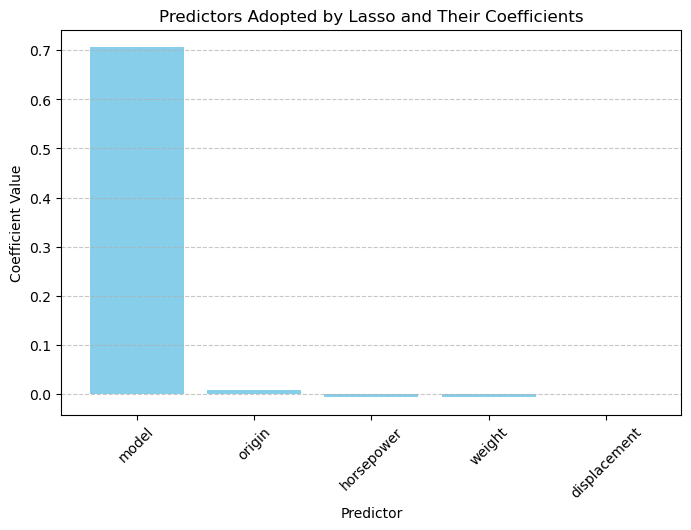

In [34]:
import matplotlib.pyplot as plt

# Sort predictors by absolute coefficient value
adopted_predictors_sorted = adopted_predictors.reindex(adopted_predictors['Coefficient'].abs().sort_values(ascending=False).index)

# Plot
plt.figure(figsize=(8,5))
plt.bar(adopted_predictors_sorted['Predictor'], adopted_predictors_sorted['Coefficient'], color='skyblue')
plt.title('Predictors Adopted by Lasso and Their Coefficients')
plt.ylabel('Coefficient Value')
plt.xlabel('Predictor')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Step 6: Train Models & Cross-Validation on Training Set

#### PCA

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Linear regression on PCA components
lr_pca = LinearRegression()
# Fit the linear regression model on PCA components
lr_pca.fit(X_train_pca, y_train)

# Cross-validation on PCA components
cv_pca = cross_val_score(lr_pca, X_train_pca, y_train, cv=5, scoring='r2') # R² as the scoring metric
print("PCA CV R²:", np.mean(cv_pca))

PCA CV R²: 0.7802001024476792


#### Get the regression coefficients

In [ ]:
# Print coefficients and intercept of the linear regression model on PCA components
print("Intercept:", lr_pca.intercept_)
print("Coefficients:", lr_pca.coef_)

Intercept: 23.637591240875913
Coefficients: [-3.19519134  0.30332474  2.26430233 -0.30713578]


#### PCA regression equation

mpg=23.6376−3.1952⋅PC1​+0.3033⋅PC2​+2.2643⋅PC3​−0.3071⋅PC4​

In [41]:
import pandas as pd

coef_df = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(lr_pca.coef_))],
    "Coefficient": lr_pca.coef_
})

print("Intercept:", lr_pca.intercept_)
print(coef_df)

Intercept: 23.637591240875913
  Component  Coefficient
0       PC1    -3.195191
1       PC2     0.303325
2       PC3     2.264302
3       PC4    -0.307136


### Lasso Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# LASSO regression on original features
lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_train, y_train)

# Cross-validation on original features with LASSO
cv_lasso = cross_val_score(lasso_model, X_train, y_train, cv=5, scoring='r2') # R² as the scoring metric
print("LASSO CV R²:", np.mean(cv_lasso))

LASSO CV R²: 0.7944297961499573


#### Get the regression coefficients

In [ ]:
# Print coefficients and intercept of the LASSO regression model on original features
print("Intercept:", lasso_model.intercept_)
print("Coefficients:", lasso_model.coef_)

Intercept: -10.309752604395523
Coefficients: [ 0.00000000e+00 -6.49152442e-03 -6.59882951e-03  4.74415319e-04
  0.00000000e+00  7.06374996e-01  7.47919462e-03]


#### Lasso regression equation

mpg=10.309752604395523​−0.00649⋅weight−0.00660⋅horsepower+0.00047⋅displacement+0.70638⋅model+0.00748⋅origin

In [43]:
import pandas as pd

coef_df = pd.DataFrame({
    "Predictor": X_train.columns,
    "Coefficient": lasso_model.coef_
})

print("Intercept:", lasso_model.intercept_)
print(coef_df)

Intercept: -10.309752604395523
      Predictor  Coefficient
0     cylinders     0.000000
1        weight    -0.006492
2    horsepower    -0.006599
3  displacement     0.000474
4  acceleration     0.000000
5         model     0.706375
6        origin     0.007479


### Step 7: Evaluate on Test Set

#### PCA

In [30]:

test_pca = lr_pca.score(X_test_pca, y_test)

print("Test R² PCA:", test_pca)

Test R² PCA: 0.7722452020221541


#### Lasso Regression

In [31]:
test_lasso = lasso_model.score(X_test, y_test)

print("Test R² LASSO:", test_lasso)

Test R² LASSO: 0.8066878541413633


### Interpretation

For prediction purposes: Lasso is clearly the better choice here. It keeps the important predictors, shrinks irrelevant ones to zero, and avoids the potential information loss that can happen when using PCA components.

For interpretability: Lasso is also better than PCA, because the coefficients correspond to the original variables, so I can see exactly which predictors matter for mpg.

Why PCA might underperform here:
PCA creates linear combinations of all predictors, which can blur the influence of individual variables.
Some variance captured by PCs might not be relevant for predicting mpg, so the model could be less accurate.


### Conclusion: 

Lasso regression is outperforming PCA regression on both train and test sets.
Higher train R² → Lasso fits the training data well.
Higher test R² → Lasso generalizes better to unseen data, so it’s not overfitting compared to PCA regression.